<a href="https://colab.research.google.com/github/george-marcus/ml-neural-networks/blob/main/MLP_MakeMore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# from google.colab import drive
# drive.mount('/content/drive')

%matplotlib inline

In [74]:
words = open('names.txt', 'r').read().splitlines()
# words = open('/content/drive/MyDrive/Colab Notebooks/names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
block_size = 3

In [75]:
def build_dataset(words):
  X,Y = [],[]
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X,Y

In [76]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    w_std = (5/3)/((fan_in)**0.5)
    g = torch.Generator().manual_seed(2147483647)
    self.W = torch.randn((fan_in, fan_out), generator=g) * w_std
    self.b = torch.randn(fan_out, generator=g) * 0.01 if bias else None
    self.parameters = [self.W]
    if bias:
      self.parameters.append(self.b)

  def __call__(self, x):
    if self.b is not None:
      return x @ self.W + self.b
    else:
      return x @ self.W

In [77]:
class BatchNorm1d:
  def __init__(self, dim,eps=1e-5, momentum=0.999):
    self.gain = torch.ones((1, dim))
    self.bias = torch.zeros((1, dim))
    self.momentum = momentum
    self.training = True    
    self.eps = eps
    self.parameters = [self.gain, self.bias]

    self.running_mean = torch.zeros((1, dim))
    self.running_var = torch.ones((1, dim))

  def __call__(self, x):
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gain * xhat + self.bias
    if self.training:
        with torch.no_grad():
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * xmean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * xvar
    return self.out

In [78]:
class Tanh:
  def __init__(self):
    self.parameters = []
  
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

In [79]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
xtr,ytr = build_dataset(words[:n1])
xdev,ydev = build_dataset(words[n1:n2])
xte,yte = build_dataset(words[n2:])

g = torch.Generator().manual_seed(2147483647)
embbedding_vectors_count = 10
hidden_layer_neurons_count = 200
vocab_size = 27

C = torch.randn((vocab_size, embbedding_vectors_count), generator=g)
layers =[
  Linear(block_size * embbedding_vectors_count, hidden_layer_neurons_count, bias=False), BatchNorm1d(hidden_layer_neurons_count), Tanh(),
  Linear(hidden_layer_neurons_count, hidden_layer_neurons_count, bias=False), BatchNorm1d(hidden_layer_neurons_count), Tanh(),
  Linear(hidden_layer_neurons_count, hidden_layer_neurons_count, bias=False), BatchNorm1d(hidden_layer_neurons_count), Tanh(),
  Linear(hidden_layer_neurons_count, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
with torch.no_grad():
  layers[-1].gain *= 0.1
  for layer in layers:
    if isinstance(layer, Linear):
      layer.W *= 5/3

parameters = []
for layer in layers:
  parameters.extend(layer.parameters)
parameters.append(C)

for p in parameters:
  p.requires_grad = True

In [80]:
max_epochs = 200000
batch_size = 32
lossi = []

for i in range(max_epochs):
  # mini batch construct
  ix = torch.randint(0,xtr.shape[0],(batch_size,))
  Xb = xtr[ix]
  Yb = ytr[ix]
  # forward pass
  emb = C[Xb]
  x = emb.view(emb.shape[0], -1)
  # layers
  for layer in layers:
      x = layer(x)
    
  loss = F.cross_entropy(x,Yb)

  #  backward pass
  for p in parameters:
    p.grad = None
  
  loss.backward()
  
  lr = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data += -lr * p.grad
    
  if i % 10000 == 0:
    print(f'{i:7d}/{max_epochs:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3291
  10000/ 200000: 2.2815
  20000/ 200000: 2.3205
  30000/ 200000: 2.4467
  40000/ 200000: 2.3713
  50000/ 200000: 2.4429
  60000/ 200000: 2.0752
  70000/ 200000: 1.9685
  80000/ 200000: 2.3141
  90000/ 200000: 2.1708
 100000/ 200000: 1.9687
 110000/ 200000: 2.0637
 120000/ 200000: 2.0948
 130000/ 200000: 2.0287
 140000/ 200000: 2.0668
 150000/ 200000: 2.1113
 160000/ 200000: 2.2558
 170000/ 200000: 2.0079
 180000/ 200000: 1.8334
 190000/ 200000: 2.1448


In [81]:
# plt.figure(figsize=(20,10))
# plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [82]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (xtr,ytr),
        'dev': (xdev,ydev),
        'test': (xte,yte),
    }[split]
    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False
        x = layer(x)
    loss = F.cross_entropy(x,y)
    print(split, loss.item())
    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = True
    
split_loss('train')
split_loss('dev')

train 2.0008623600006104
dev 2.0787813663482666


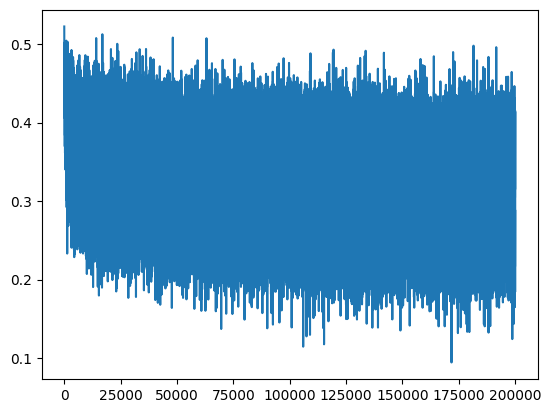

In [83]:
plt.plot(lossi)

In [84]:
# sample from the model
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor(context)]
    x = emb.view(1,-1)
    for layer in layers:
        x = layer(x)
    logits = x 
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

beni.
alika.
kaidalynsley.
triela.
akingston.
beth.
darrenlee.
camella.
cha.
saad.
ky.
krist.
kassi.
zoisely.
jamari.
eugustine.
anna.
zamine.
mia.
foly.
